# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [24]:
# Import necessary modules from PIL
from PIL import Image, ImageOps, ImageEnhance
import matplotlib.pyplot as plt
import numpy as np 
from skimage import data

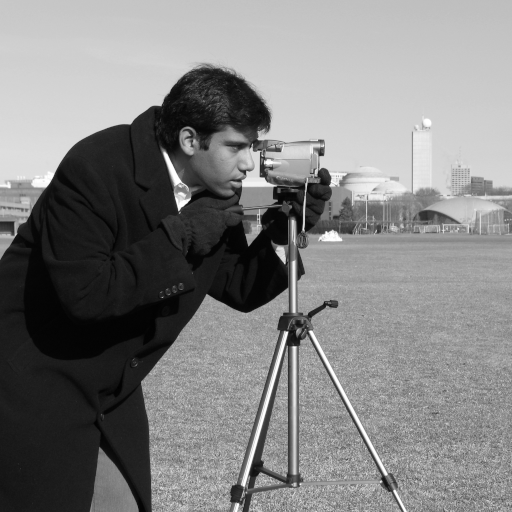

In [26]:
# Load the image
image = data.camera()
img = Image.fromarray(image)
img

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [27]:
# Get the size of the image
width, height = img.size

# scaling factors
cx, cy = 2, 2


In [28]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
scaled_img = img.resize((width * cx, height * cy), Image.Resampling.LANCZOS)


In [29]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print(f"Original size: {img.size}")
print(f"Scaled size: {scaled_img.size}")

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

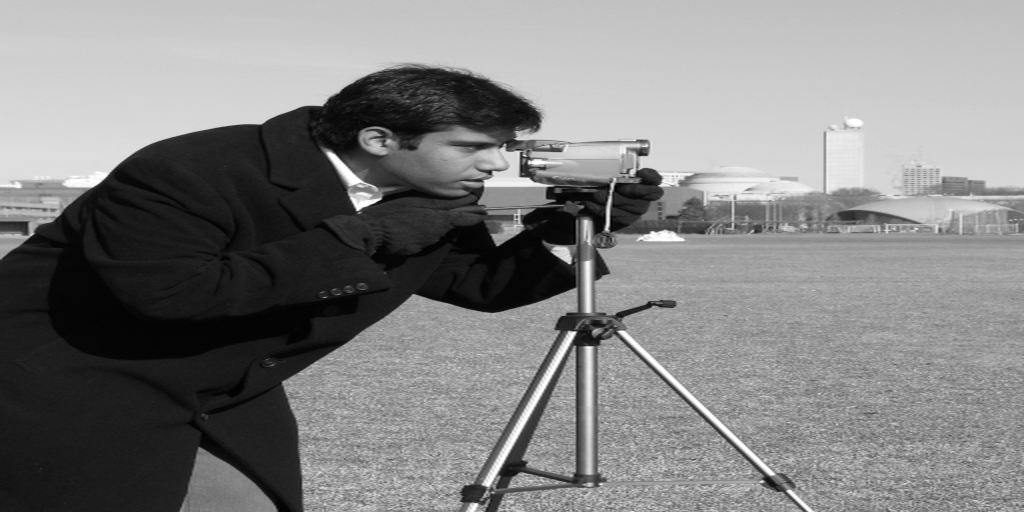

In [40]:
stretched_img = img.resize((width * 2, height * 1), Image.Resampling.LANCZOS)
stretched_img

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

In [31]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img.rotate(120, expand=True)
rotated_img.save("task1_2_rotated.jpg")
print(f"Rotated size: {rotated_img.size}")


Rotated size: (700, 700)


### 3. Shear

In [32]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size


In [33]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shx = 0.5
shy = 0
tx = 0
ty = 0


In [34]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
new_width = int(width + height * shx)
sheared_img = img.transform((new_width, height), Image.AFFINE, (1, shx, tx, shy, 1, ty), resample=Image.Resampling.BICUBIC)


In [35]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.save("task1_3_sheared.jpg")


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

In [42]:
width, height = img.size
factors = [0.1, 0.3, 0.8]

for shx in factors:
    new_width = int(width + height * shx)
    sheared = img.transform((new_width, height), Image.AFFINE, (1, shx, 0, 0, 1, 0), resample=Image.Resampling.BICUBIC)
    sheared.save(f"sheared_x_{shx}.jpg")
    print(f"Shear factor {shx}: output size = {sheared.size}")

Shear factor 0.1: output size = (563, 512)
Shear factor 0.3: output size = (665, 512)
Shear factor 0.8: output size = (921, 512)


— Switch from X-axis to Y-axis shear matrix

In [43]:
shy = 0.5
new_height = int(height + width * shy)

sheared_y = img.transform((width, new_height), Image.AFFINE, (1, 0, 0, shy, 1, 0), resample=Image.Resampling.BICUBIC)
sheared_y.save("sheared_y_0.5.jpg")
print(f"Y-axis sheared size: {sheared_y.size}")

Y-axis sheared size: (512, 768)


— Update the canvas multiplier to match your new factor

In [44]:
shx = 0.8
canvas_width = int(width + height * shx)
canvas_height = height

sheared_dynamic = img.transform((canvas_width, canvas_height), Image.AFFINE, (1, shx, 0, 0, 1, 0), resample=Image.Resampling.BICUBIC)
sheared_dynamic.save("sheared_dynamic_canvas.jpg")

— Try combining X and Y shear in one matrix

In [46]:
shx = 0.3
shy = 0.3

combined_width = int(width + height * shx)
combined_height = int(height + width * shy)

sheared_xy = img.transform((combined_width, combined_height), Image.AFFINE, (1, shx, 0, shy, 1, 0), resample=Image.Resampling.BICUBIC)
sheared_xy.save("sheared_combined_xy.jpg")
print(f"Combined shear size: {sheared_xy.size}")

Combined shear size: (665, 665)


# Intensity Transformations
Negative · Log · Power Law (Gamma)

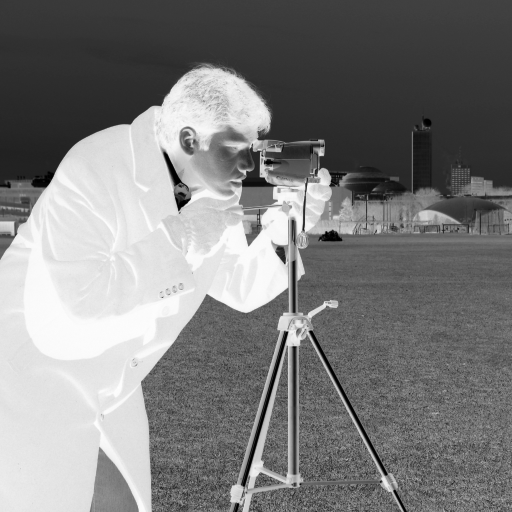

In [47]:
# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
arr = np.array(img, dtype=np.float64)
neg_arr = (255 - arr).astype(np.uint8)
img_neg1 = Image.fromarray(neg_arr)
img_neg1

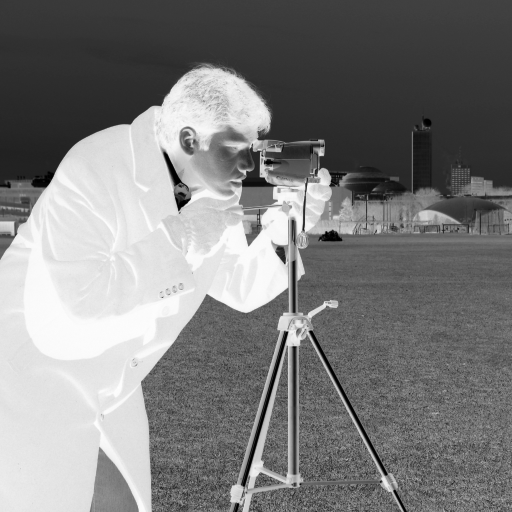

In [48]:
# Method 2: PIL's ImageOps
img_neg2 = ImageOps.invert(img.convert('L'))
img_neg2

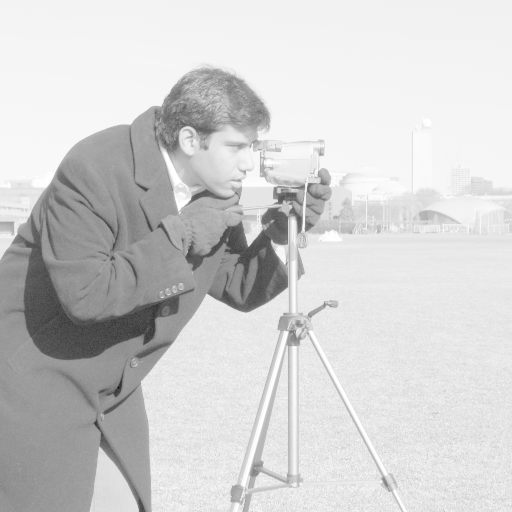

In [49]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)


# Apply the log transformation to each pixel
arr = np.array(img, dtype=np.float64)
log_transformed_arr = c * np.log(1 + arr)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)
log_img = Image.fromarray(log_transformed_arr)
log_img

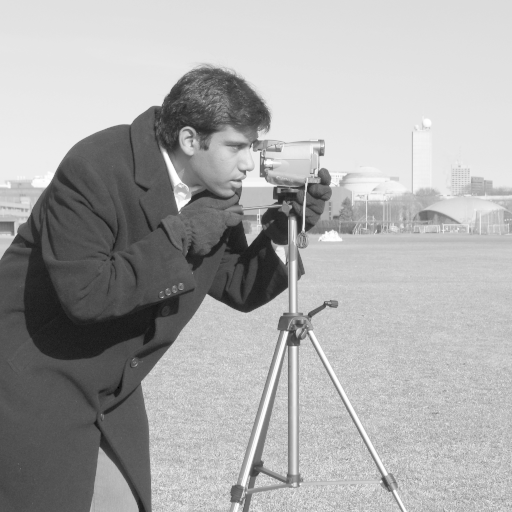

In [50]:
# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5
c_gamma = 255 / (255 ** gamma)

arr = np.array(img, dtype=np.float64)
gamma_arr = c_gamma * (arr ** gamma)
gamma_arr = np.clip(gamma_arr, 0, 255).astype(np.uint8)
gamma_img = Image.fromarray(gamma_arr)
gamma_img